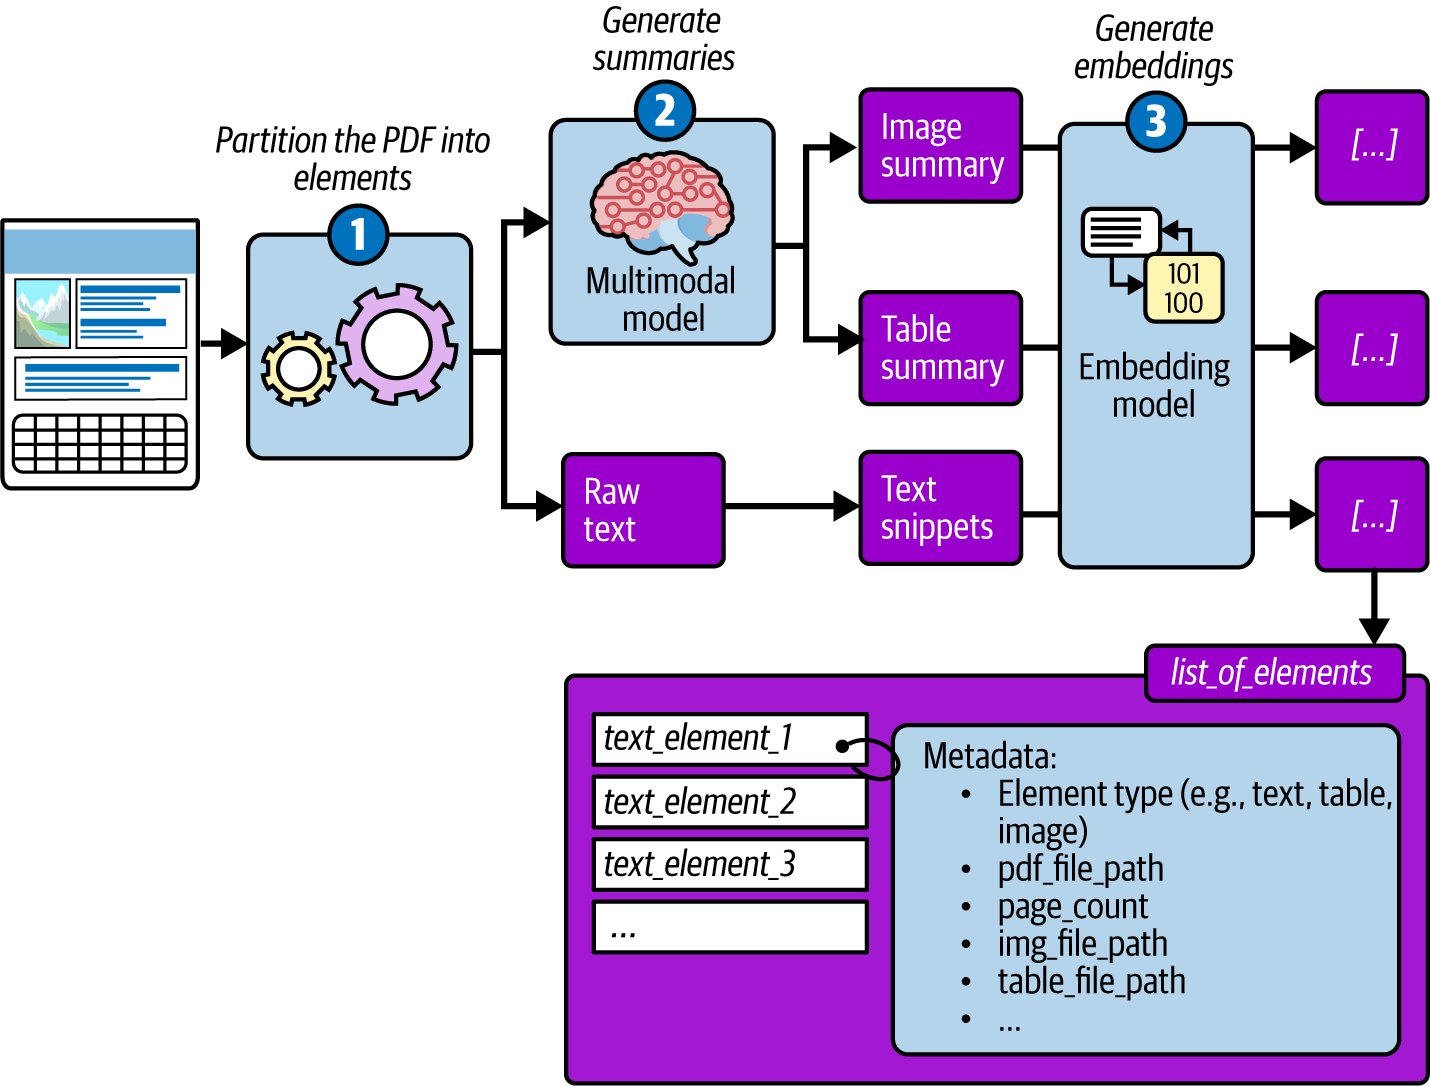

In [1]:
from IPython.display import Image, display
display(Image(filename="../images/16.png", width=500, height=500))

In [ ]:
sudo apt-get install poppler-utils

In [ ]:
from unstructured.partition.pdf import partition_pdf
import os

# Set the OCR agent to tesseract
os.environ["OCR_AGENT"] = "tesseract"

pdf_file_path = "../datasets/pdf_files/adult_data_article.pdf"
image_output_dir = "../datasets/extracted_content_from_pdfs/images"

# Create output directory if it doesn't exist
os.makedirs(image_output_dir, exist_ok=True)

# Get elements by using the function extract_pdf_elements
raw_pdf_elements = partition_pdf(
    filename=pdf_file_path,
    extract_images_in_pdf=True,
    extract_image_block_types=["Image", "Table"],
    extract_image_block_to_payload=False,
    extract_image_block_output_dir=image_output_dir,
)

# Categorize elements by type
tables = []
texts = []
titles = []

# Fill the just created lists with the elements
for element in raw_pdf_elements:
    element_type = str(type(element))
    if "unstructured.documents.elements.Table" in element_type:
        tables.append(str(element))
    elif "unstructured.documents.elements.NarrativeText" in element_type:
        texts.append(str(element))
    elif "unstructured.documents.elements.Title" in element_type:
        titles.append(str(element))